# Analisis Exploratorio de los Datos
### Mary Kay de Mexico — Market Intelligence
**Autora:** Steffany Lara | **Fecha:** 18 de febrero del 2026

**Objetivo:** Comprender si hay alguna relacion entre la fecha de primer pedido en el mes y la frecuencia / monto de reorden de las consultoras.

```
Entrada : Listado de Consultoras y sus ordenes (multiples) julio-octubre 2025 y enero 2026
Meses   : 202507, 202508, 202509, 202510, 202601

Preguntas clave:
  1. Cantidad de consultoras unicas por grupo de dias (1-8, 9-16, 17-24, 25-fin)
  2. De cada grupo, % que colocan 1+ orden adicional en el mismo mes (reorden)
  3. Wholesale promedio por grupo vs. consultoras que NO ordenan en primeros dias
  4. Insights adicionales: tendencia por mes, perfil de carrera, nuevas vs. activas
```

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Paleta Mary Kay
PINK       = '#E91E8C'
PINK_LIGHT = '#F8BBD9'
PINK_DARK  = '#C2185B'
PINK_MED   = '#F06292'
GRAY       = '#616161'
BG         = '#FFF0F6'

GRUPO_ORDER = ['Dias 1-8', 'Dias 9-16', 'Dias 17-24', 'Dias 25-fin']
COLORES     = [PINK, PINK_DARK, PINK_MED, GRAY]
MARKERS     = {'Dias 1-8': 'o', 'Dias 9-16': 's', 'Dias 17-24': '^', 'Dias 25-fin': 'D'}

# --- Cargar datos ---
df = pd.read_csv("DB/analysis_MonthlyOrdersByDay_PV.csv")

# --- Parsear fechas ---
df['OrderDateKEY']  = pd.to_datetime(df['OrderDateKEY'].astype(str),  format='%Y%m%d')
df['OrderMonthKey'] = pd.to_datetime(df['OrderMonthKey'].astype(str), format='%Y%m')
df['Day']           = df['OrderDateKEY'].dt.day
df['Month']         = df['OrderMonthKey'].dt.strftime('%b %Y')
df['MonthSort']     = df['OrderMonthKey']

print(f"Registros totales : {len(df):,}")
print(f"Meses en el dataset: {sorted(df['Month'].unique())}")
df.head()

Registros totales : 415,274
Meses en el dataset: ['Aug 2025', 'Jan 2026', 'Jul 2025', 'Oct 2025', 'Sep 2025']


,OrderDateKEY,PurchaserConsultantKEY,ConsultantNumber,CareerLevelCode,OrderMonthKey,OrderKEY,OrderingConsultantIndicator,NewRecruitIndicator,ProductionOrderCount,TotalWhosale,Day,Month,MonthSort
0,2025-07-01,1376,55878,90,2025-07-01,40854901,1,0,1,38942.0,1,Jul 2025,2025-07-01
1,2025-07-01,2341,222724,70,2025-07-01,40854752,1,0,2,2459.0,1,Jul 2025,2025-07-01
2,2025-07-01,2684,857565,70,2025-07-01,40854814,1,0,4,6504.0,1,Jul 2025,2025-07-01
3,2025-07-01,2975,44290,70,2025-07-01,40854619,1,0,3,21358.0,1,Jul 2025,2025-07-01
4,2025-07-01,3028,89384,10,2025-07-01,40855048,1,0,3,3709.0,1,Jul 2025,2025-07-01


In [17]:
# ♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥ ASIGNAR GRUPO DE DIAS A CADA ORDEN

def asignar_grupo(day):
    if   1  <= day <= 8:  return 'Dias 1-8'
    elif 9  <= day <= 16: return 'Dias 9-16'
    elif 17 <= day <= 24: return 'Dias 17-24'
    else:                 return 'Dias 25-fin'

df['GrupoDias'] = df['Day'].apply(asignar_grupo)
df['GrupoDias'] = pd.Categorical(df['GrupoDias'], categories=GRUPO_ORDER, ordered=True)

print("Distribucion de registros por grupo:")
print(df['GrupoDias'].value_counts().sort_index())

Distribucion de registros por grupo:
GrupoDias
Dias 1-8        41795
Dias 9-16       60779
Dias 17-24      67089
Dias 25-fin    245611
Name: count, dtype: int64


In [18]:
# ♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥ PRIMER PEDIDO DE CADA CONSULTORA EN EL MES

primer = (
    df.sort_values('OrderDateKEY')
      .groupby(['ConsultantNumber', 'MonthSort', 'Month'])
      .agg(
          PrimerDia      = ('Day', 'first'),
          TotalOrdenes   = ('OrderKEY', 'nunique'),
          TotalWholesale = ('TotalWhosale', 'sum'),
          CareerLevel    = ('CareerLevelCode', 'first'),
          NewRecruit     = ('NewRecruitIndicator', 'first')
      )
      .reset_index()
)

primer['GrupoPrimerOrden'] = primer['PrimerDia'].apply(asignar_grupo)
primer['GrupoPrimerOrden'] = pd.Categorical(primer['GrupoPrimerOrden'], categories=GRUPO_ORDER, ordered=True)
primer['Reordena']         = primer['TotalOrdenes'] > 1
primer['AvgWholesale']     = primer['TotalWholesale'] / primer['TotalOrdenes']

print(f"Consultoras-mes unicos analizados: {len(primer):,}")
primer.head()

Consultoras-mes unicos analizados: 307,778


,ConsultantNumber,MonthSort,Month,PrimerDia,TotalOrdenes,TotalWholesale,CareerLevel,NewRecruit,GrupoPrimerOrden,Reordena,AvgWholesale
0,00BUF3,2025-07-01,Jul 2025,30,1,2933.0,10,0,Dias 25-fin,False,2933.0
1,00BUJ5,2025-07-01,Jul 2025,14,1,3910.5,10,0,Dias 9-16,False,3910.5
2,00BUJ5,2025-08-01,Aug 2025,11,1,2161.8,10,0,Dias 9-16,False,2161.8
3,00BUJ5,2025-09-01,Sep 2025,3,1,4443.5,10,0,Dias 1-8,False,4443.5
4,00BUJ5,2025-10-01,Oct 2025,9,2,35266.0,10,0,Dias 9-16,True,17633.0


In [19]:
# ♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥ RESUMEN GLOBAL (Jul 2025 - Ene 2026)

resumen = (
    primer.groupby('GrupoPrimerOrden', observed=True)
          .agg(
              ConsultantasUnicas = ('ConsultantNumber', 'nunique'),
              PctReorden         = ('Reordena', 'mean'),
              AvgWholesale       = ('AvgWholesale', 'mean'),
              MedianaWholesale   = ('AvgWholesale', 'median')
          )
          .reset_index()
)
resumen['PctReorden_%']     = (resumen['PctReorden'] * 100).round(1)
resumen['AvgWholesale']     = resumen['AvgWholesale'].round(0)
resumen['MedianaWholesale'] = resumen['MedianaWholesale'].round(0)

print("  RESUMEN GLOBAL (Jul 2025 - Ene 2026)")
print(resumen[['GrupoPrimerOrden','ConsultantasUnicas','PctReorden_%','AvgWholesale','MedianaWholesale']].to_string(index=False))

  RESUMEN GLOBAL (Jul 2025 - Ene 2026)
GrupoPrimerOrden  ConsultantasUnicas  PctReorden_%  AvgWholesale  MedianaWholesale
        Dias 1-8               28107          53.5        4576.0            3699.0
       Dias 9-16               36613          43.5        4528.0            3670.0
      Dias 17-24               39223          28.0        4506.0            3700.0
     Dias 25-fin               97763           5.5        4585.0            3695.0


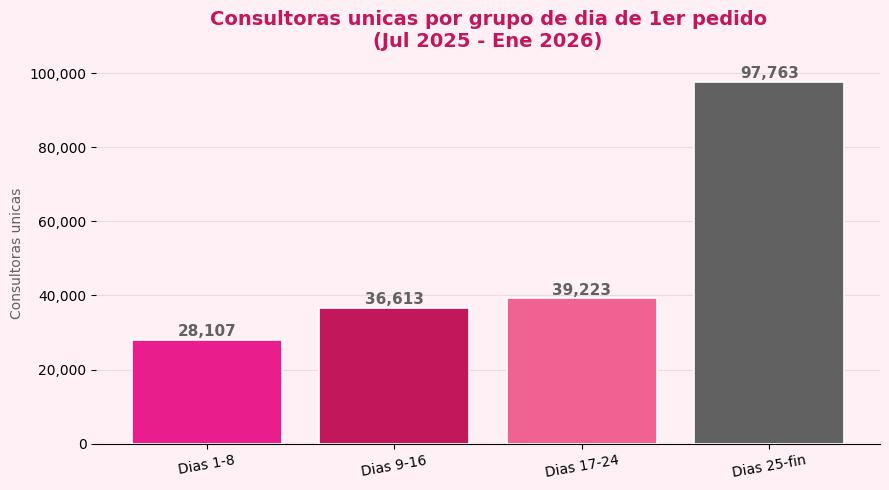

In [20]:
# ♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥ GRAFICA: Consultoras unicas por grupo de dias

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.set_facecolor(BG)

bars = ax.bar(resumen['GrupoPrimerOrden'], resumen['ConsultantasUnicas'],
              color=COLORES, edgecolor='white', linewidth=1.2, zorder=3)

for bar, val in zip(bars, resumen['ConsultantasUnicas']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold', color=GRAY)

ax.set_title('Consultoras unicas por grupo de dia de 1er pedido\n(Jul 2025 - Ene 2026)',
             fontsize=14, fontweight='bold', color=PINK_DARK, pad=12)
ax.set_ylabel('Consultoras unicas', color=GRAY)
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.spines[['top','right','left']].set_visible(False)
plt.xticks(rotation=10, fontsize=10)
plt.tight_layout()
plt.show()

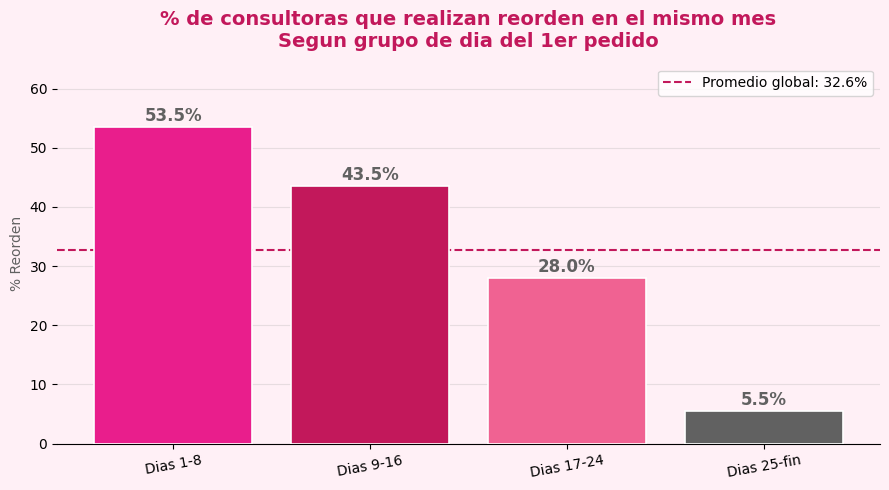

In [21]:
# ♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥ GRAFICA: % Reorden por grupo

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.set_facecolor(BG)

bars = ax.bar(resumen['GrupoPrimerOrden'], resumen['PctReorden_%'],
              color=COLORES, edgecolor='white', linewidth=1.2, zorder=3)

for bar, val in zip(bars, resumen['PctReorden_%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', va='bottom', fontsize=12, fontweight='bold', color=GRAY)

ax.axhline(resumen['PctReorden_%'].mean(), color=PINK_DARK, linestyle='--', linewidth=1.5,
           label=f"Promedio global: {resumen['PctReorden_%'].mean():.1f}%")
ax.legend(fontsize=10)

ax.set_title('% de consultoras que realizan reorden en el mismo mes\nSegun grupo de dia del 1er pedido',
             fontsize=14, fontweight='bold', color=PINK_DARK, pad=12)
ax.set_ylabel('% Reorden', color=GRAY)
ax.set_ylim(0, resumen['PctReorden_%'].max() * 1.2)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.spines[['top','right','left']].set_visible(False)
plt.xticks(rotation=10, fontsize=10)
plt.tight_layout()
plt.show()

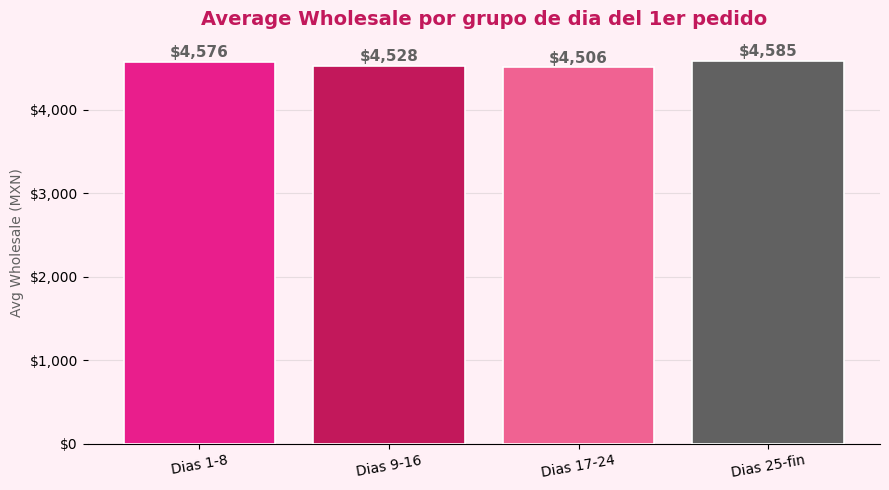

In [22]:
# ♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥ GRAFICA: Wholesale promedio por grupo

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.set_facecolor(BG)

bars = ax.bar(resumen['GrupoPrimerOrden'], resumen['AvgWholesale'],
              color=COLORES, edgecolor='white', linewidth=1.2, zorder=3)

for bar, val in zip(bars, resumen['AvgWholesale']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color=GRAY)

ax.set_title('Average Wholesale por grupo de dia del 1er pedido',
             fontsize=14, fontweight='bold', color=PINK_DARK, pad=12)
ax.set_ylabel('Avg Wholesale (MXN)', color=GRAY)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.spines[['top','right','left']].set_visible(False)
plt.xticks(rotation=10, fontsize=10)
plt.tight_layout()
plt.show()

In [23]:
# ♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥ ANALISIS POR MES — % Reorden

resumen_mes = (
    primer.groupby(['MonthSort','Month','GrupoPrimerOrden'], observed=True)
          .agg(
              ConsultantasUnicas = ('ConsultantNumber', 'nunique'),
              PctReorden         = ('Reordena', 'mean'),
              AvgWholesale       = ('AvgWholesale', 'mean')
          )
          .reset_index()
          .sort_values(['MonthSort','GrupoPrimerOrden'])
)
resumen_mes['PctReorden_%'] = (resumen_mes['PctReorden'] * 100).round(1)
resumen_mes['AvgWholesale'] = resumen_mes['AvgWholesale'].round(0)

pivot_reorden = resumen_mes.pivot_table(
    index='GrupoPrimerOrden', columns='Month', values='PctReorden_%'
)
col_order = resumen_mes.sort_values('MonthSort')['Month'].unique()
pivot_reorden = pivot_reorden[col_order]

print("  % Reorden por Grupo x Mes")
print(pivot_reorden.to_string())

  % Reorden por Grupo x Mes
Month             Jul 2025  Aug 2025  Sep 2025  Oct 2025  Jan 2026
GrupoPrimerOrden                                                  
Dias 1-8              58.5      53.9      50.8      50.8      51.9
Dias 9-16             52.2      37.3      38.5      47.6      38.8
Dias 17-24            37.9      38.5      20.4      22.1      21.6
Dias 25-fin            7.9       4.2       3.5       7.6       3.6


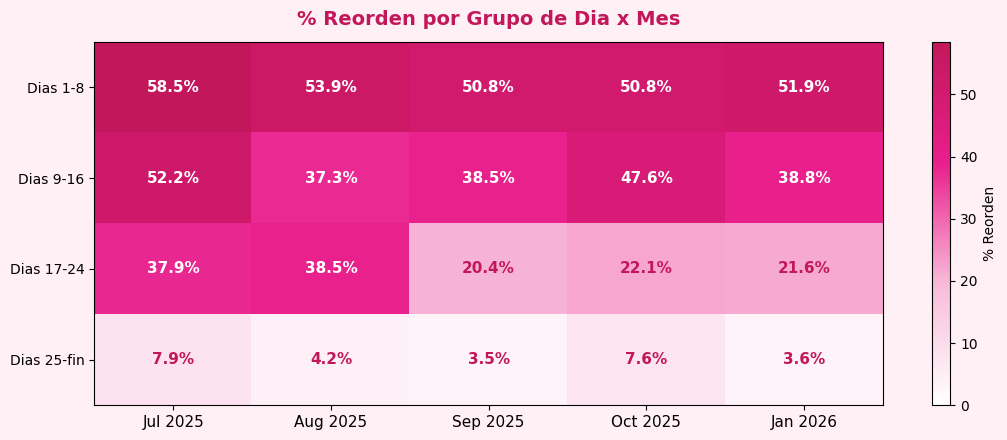

In [24]:
# ♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥ HEATMAP: % Reorden por grupo x mes

cmap = LinearSegmentedColormap.from_list('mk_pink', ['#FFFFFF', PINK_LIGHT, PINK, PINK_DARK])

fig, ax = plt.subplots(figsize=(11, 4.5), facecolor=BG)
ax.set_facecolor(BG)

data = pivot_reorden.values
im = ax.imshow(data, cmap=cmap, aspect='auto', vmin=0, vmax=data.max())

ax.set_xticks(range(len(pivot_reorden.columns)))
ax.set_xticklabels(pivot_reorden.columns, fontsize=11)
ax.set_yticks(range(len(pivot_reorden.index)))
ax.set_yticklabels(pivot_reorden.index, fontsize=10)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                    fontsize=11, fontweight='bold',
                    color='white' if val > data.max()*0.6 else PINK_DARK)

ax.set_title('% Reorden por Grupo de Dia x Mes', fontsize=14, fontweight='bold', color=PINK_DARK, pad=12)
plt.colorbar(im, ax=ax, label='% Reorden')
plt.tight_layout()
plt.show()

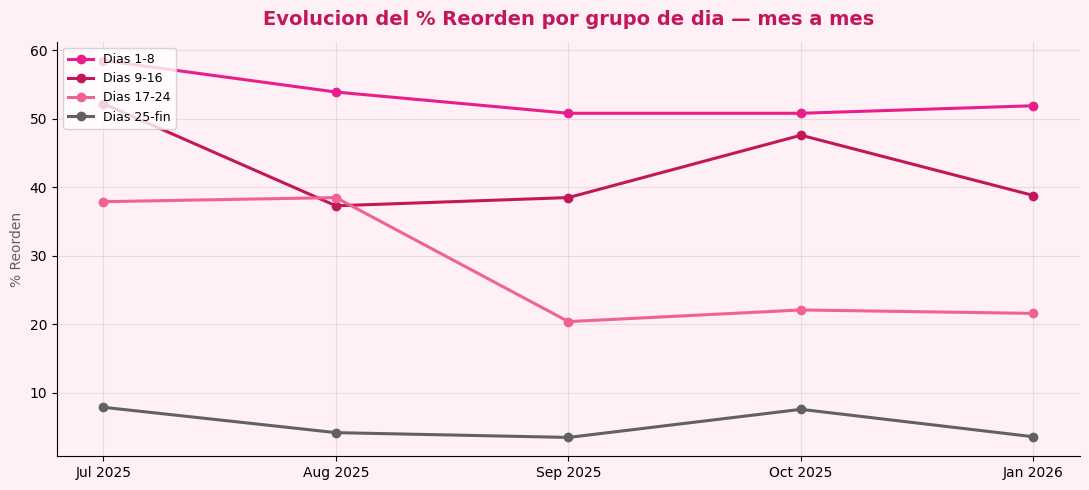

In [25]:
# ♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥ LINEAS: % Reorden por mes para cada grupo

colores_grupos = dict(zip(GRUPO_ORDER, COLORES))

fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
ax.set_facecolor(BG)

for grupo, sub in resumen_mes.sort_values('MonthSort').groupby('GrupoPrimerOrden', observed=True):
    ax.plot(sub['Month'], sub['PctReorden_%'], marker='o', linewidth=2.2,
            label=str(grupo), color=colores_grupos.get(str(grupo), PINK))

ax.set_title('Evolucion del % Reorden por grupo de dia — mes a mes',
             fontsize=14, fontweight='bold', color=PINK_DARK, pad=12)
ax.set_ylabel('% Reorden', color=GRAY)
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

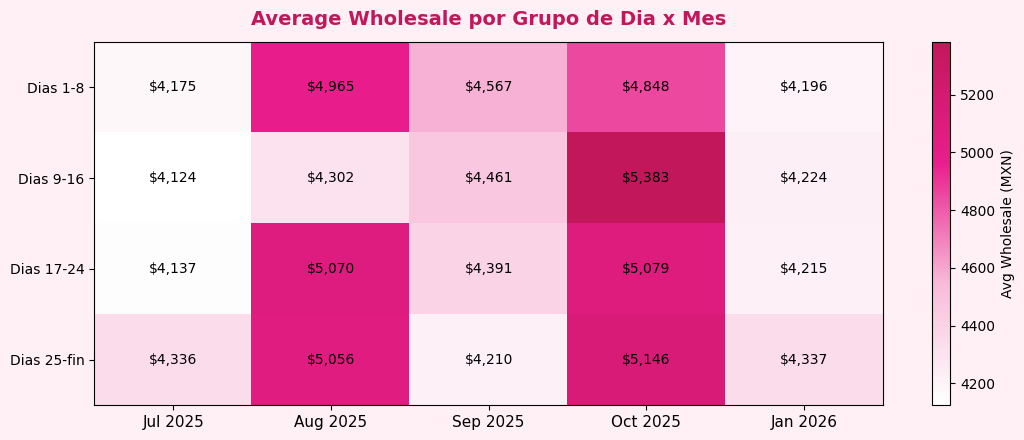

In [26]:
# ♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥ WHOLESALE PROMEDIO POR GRUPO x MES (heatmap)

pivot_ws = resumen_mes.pivot_table(
    index='GrupoPrimerOrden', columns='Month', values='AvgWholesale'
)[col_order]

fig, ax = plt.subplots(figsize=(11, 4.5), facecolor=BG)
ax.set_facecolor(BG)

data_ws = pivot_ws.values
im2 = ax.imshow(data_ws, cmap=cmap, aspect='auto')

ax.set_xticks(range(len(pivot_ws.columns)))
ax.set_xticklabels(pivot_ws.columns, fontsize=11)
ax.set_yticks(range(len(pivot_ws.index)))
ax.set_yticklabels(pivot_ws.index, fontsize=10)

for i in range(data_ws.shape[0]):
    for j in range(data_ws.shape[1]):
        val = data_ws[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'${val:,.0f}', ha='center', va='center',
                    fontsize=10, 
                    color='black' if val > np.nanmax(data_ws)*0.6 else PINK_DARK)

ax.set_title('Average Wholesale por Grupo de Dia x Mes', fontsize=14, fontweight='bold', color=PINK_DARK, pad=12)
plt.colorbar(im2, ax=ax, label='Avg Wholesale (MXN)')
plt.tight_layout()
plt.show()

In [27]:
# ♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥ NIVEL DE CARRERA POR GRUPO

career_map = {10: 'Consultora', 20: 'Estrella', 30: 'Team Leader',
              40: 'Directora Ventas', 50: 'Directora Senior', 60: 'Directora Futura',
              70: 'Directora', 80: 'Dir. Senior', 90: 'Dir. Ejecutiva'}

primer['CareerLabel'] = primer['CareerLevel'].map(career_map).fillna(primer['CareerLevel'].astype(str))

career_grupo = (
    primer.groupby(['GrupoPrimerOrden','CareerLabel'], observed=True)
          .agg(Count=('ConsultantNumber','nunique'), PctReorden=('Reordena','mean'))
          .reset_index()
)

top_careers = primer['CareerLabel'].value_counts().head(5).index
cg_top = career_grupo[career_grupo['CareerLabel'].isin(top_careers)]

pivot_career = cg_top.pivot_table(index='CareerLabel', columns='GrupoPrimerOrden',
                                   values='PctReorden').round(3) * 100

print("  % Reorden por Nivel de Carrera x Grupo de Dia")
print(pivot_career.to_string())

  % Reorden por Nivel de Carrera x Grupo de Dia
GrupoPrimerOrden  Dias 1-8  Dias 9-16  Dias 17-24  Dias 25-fin
CareerLabel                                                   
45                    76.4       66.2        45.9         10.4
Consultora            46.3       38.8        23.4          4.2
Directora             90.5       84.2        85.1         45.8
Directora Futura      90.2       85.0        84.0         42.8
Directora Senior      90.1       88.5        73.6         20.5


In [28]:
# ♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥ NUEVAS RECLUTAS VS. CONSULTORAS ACTIVAS

nuevas = (
    primer.groupby(['GrupoPrimerOrden', 'NewRecruit'], observed=True)
          .agg(Count=('ConsultantNumber','nunique'),
               PctReorden=('Reordena','mean'),
               AvgWS=('AvgWholesale','mean'))
          .reset_index()
)
nuevas['Tipo']         = nuevas['NewRecruit'].map({0:'Consultora Activa', 1:'Nueva Recluta'})
nuevas['PctReorden_%'] = (nuevas['PctReorden']*100).round(1)
nuevas['AvgWS']        = nuevas['AvgWS'].round(0)

print("  Nuevas Reclutas vs. Consultoras Activas")
print(nuevas[['GrupoPrimerOrden','Tipo','Count','PctReorden_%','AvgWS']].to_string(index=False))

  Nuevas Reclutas vs. Consultoras Activas
GrupoPrimerOrden              Tipo  Count  PctReorden_%  AvgWS
        Dias 1-8 Consultora Activa  24009          57.2 4475.0
        Dias 1-8     Nueva Recluta   4470          24.9 5357.0
       Dias 9-16 Consultora Activa  30677          47.1 4407.0
       Dias 9-16     Nueva Recluta   6458          19.5 5333.0
      Dias 17-24 Consultora Activa  31370          30.8 4332.0
      Dias 17-24     Nueva Recluta   8495          14.7 5334.0
     Dias 25-fin Consultora Activa  74035           5.7 4384.0
     Dias 25-fin     Nueva Recluta  32379           4.9 5441.0


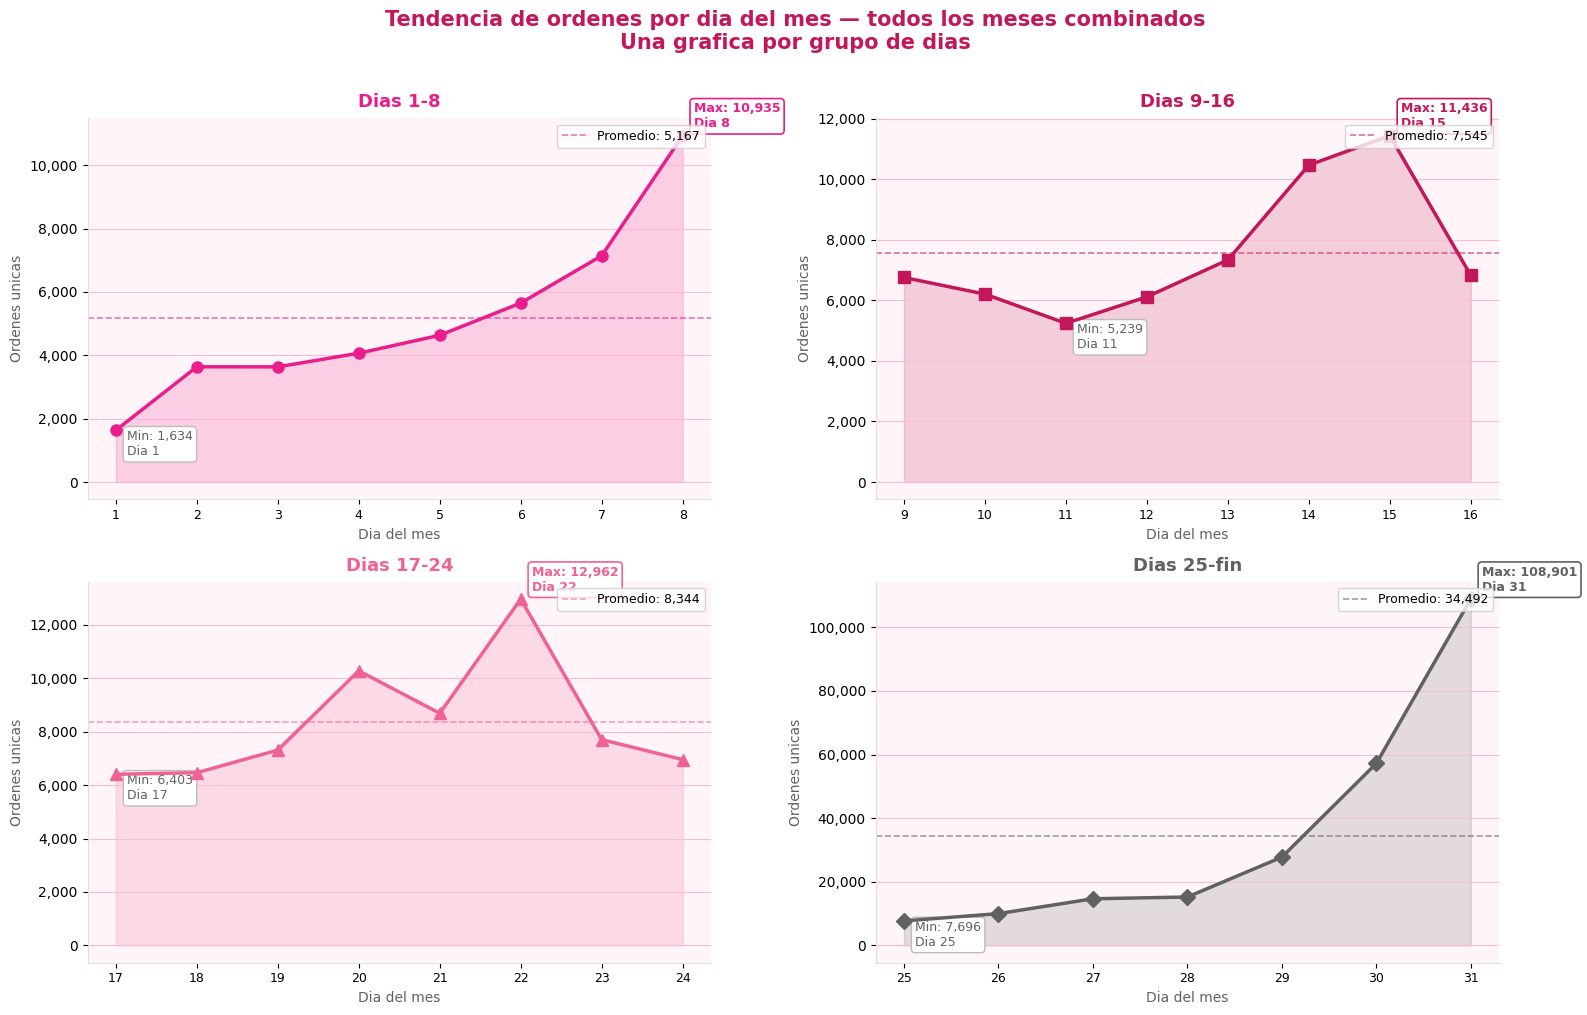

  Resumen numerico por grupo
  Dias 1-8: total=    41,335 | promedio/dia=   5,167 | dia pico=8
  Dias 9-16: total=    60,362 | promedio/dia=   7,545 | dia pico=15
  Dias 17-24: total=    66,754 | promedio/dia=   8,344 | dia pico=22
  Dias 25-fin: total=   241,441 | promedio/dia=  34,492 | dia pico=31


In [29]:
# ♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥ TENDENCIA DE CANTIDAD DE COMPRAS POR DIA (todos los meses combinados)
# Grafica de lineas: una por cada grupo, eje x = dia del mes, eje y = ordenes unicas acumuladas

# Ordenes unicas por dia del mes (suma de todos los meses)
ordenes_dia = (
    df.groupby(df['OrderDateKEY'].dt.day)['OrderKEY']
      .nunique()
      .reset_index()
      .rename(columns={'OrderDateKEY': 'Day', 'OrderKEY': 'Ordenes'})
)
ordenes_dia['Grupo'] = ordenes_dia['Day'].apply(asignar_grupo)
ordenes_dia['Grupo'] = pd.Categorical(ordenes_dia['Grupo'], categories=GRUPO_ORDER, ordered=True)

GRUPO_LIMITES = {
    'Dias 1-8'   : (1,  8,  PINK),
    'Dias 9-16'  : (9,  16, PINK_DARK),
    'Dias 17-24' : (17, 24, PINK_MED),
    'Dias 25-fin': (25, 31, GRAY),
}

# --- Subplots: una grafica por grupo ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='#FFFFFF')
fig.suptitle(
    'Tendencia de ordenes por dia del mes — todos los meses combinados\nUna grafica por grupo de dias',
    fontsize=15, fontweight='bold', color=PINK_DARK, y=1.01
)
axes = axes.flatten()

for ax_i, (grupo, (inicio, fin, color)) in enumerate(GRUPO_LIMITES.items()):
    ax = axes[ax_i]
    ax.set_facecolor('#FFF5F8')

    sub = ordenes_dia[ordenes_dia['Grupo'] == grupo].sort_values('Day')
    if sub.empty:
        ax.set_visible(False)
        continue

    x = sub['Day'].values
    y = sub['Ordenes'].values

    # Area sombreada
    ax.fill_between(x, y, alpha=0.18, color=color)

    # Linea principal
    ax.plot(x, y, color=color, marker=MARKERS[grupo], linewidth=2.5,
            markersize=8, zorder=4)

    # Anotacion del maximo
    idx_max = y.argmax()
    ax.annotate(
        f'Max: {y[idx_max]:,}\nDia {x[idx_max]}',
        xy=(x[idx_max], y[idx_max]),
        xytext=(8, 6), textcoords='offset points',
        fontsize=9, fontweight='bold', color=color,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, lw=1.2)
    )

    # Anotacion del minimo
    idx_min = y.argmin()
    ax.annotate(
        f'Min: {y[idx_min]:,}\nDia {x[idx_min]}',
        xy=(x[idx_min], y[idx_min]),
        xytext=(8, -18), textcoords='offset points',
        fontsize=9, color=GRAY,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#BDBDBD', lw=1)
    )

    # Promedio del grupo como linea punteada
    prom = y.mean()
    ax.axhline(prom, color=color, linestyle='--', linewidth=1.2, alpha=0.6,
               label=f'Promedio: {prom:,.0f}')

    ax.set_title(grupo, fontsize=13, fontweight='bold', color=color, pad=8)
    ax.set_xlabel('Dia del mes', fontsize=10, color=GRAY)
    ax.set_ylabel('Ordenes unicas', fontsize=10, color=GRAY)
    ax.set_xticks(x)
    ax.set_xticklabels([str(d) for d in x], fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax.grid(axis='y', color='#F8BBD9', linewidth=0.8, zorder=0)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#E0E0E0')
    ax.legend(fontsize=9, loc='upper right', framealpha=0.8)

plt.tight_layout()
plt.show()

print("  Resumen numerico por grupo")
for grupo in GRUPO_ORDER:
    sub = ordenes_dia[ordenes_dia['Grupo'] == grupo]
    if sub.empty: continue
    print(f'  {grupo}: total={sub["Ordenes"].sum():>10,} | '
          f'promedio/dia={sub["Ordenes"].mean():>8,.0f} | '
          f'dia pico={sub.loc[sub["Ordenes"].idxmax(), "Day"]}')

In [30]:
# ♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥ CONCLUSIONES AUTOMATICAS

r = resumen.set_index('GrupoPrimerOrden')

grp_max_reorden = r['PctReorden_%'].idxmax()
grp_max_ws      = r['AvgWholesale'].idxmax()
diff_reorden    = r.loc[GRUPO_ORDER[0], 'PctReorden_%'] - r.loc[GRUPO_ORDER[-1], 'PctReorden_%']

print("  ♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥ CONCLUSIONES DEL ANALISIS")
print(f"\nGrupo con MAYOR % reorden : {grp_max_reorden} ({r.loc[grp_max_reorden,'PctReorden_%']}%)")
print(f"Grupo con MAYOR wholesale  : {grp_max_ws} (${r.loc[grp_max_ws,'AvgWholesale']:,.0f})")
print(f"Diferencia en reorden Dias 1-8 vs Dias 25+fin: {diff_reorden:.1f} pp")
print()
print("Resumen por grupo:")
for g in GRUPO_ORDER:
    print(f"  {g}: {r.loc[g,'ConsultantasUnicas']:,} consultoras | "
          f"{r.loc[g,'PctReorden_%']}% reordena | "
          f"avg WS ${r.loc[g,'AvgWholesale']:,.0f}")
print()
print("Las consultoras que colocan su primer pedido en los dias 1-8")
print("tienden a tener comportamientos de compra mas comprometidos.")
print("Considera campanas de activacion temprana al inicio del mes.")

  ♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥ CONCLUSIONES DEL ANALISIS

Grupo con MAYOR % reorden : Dias 1-8 (53.5%)
Grupo con MAYOR wholesale  : Dias 25-fin ($4,585)
Diferencia en reorden Dias 1-8 vs Dias 25+fin: 48.0 pp

Resumen por grupo:
  Dias 1-8: 28,107 consultoras | 53.5% reordena | avg WS $4,576
  Dias 9-16: 36,613 consultoras | 43.5% reordena | avg WS $4,528
  Dias 17-24: 39,223 consultoras | 28.0% reordena | avg WS $4,506
  Dias 25-fin: 97,763 consultoras | 5.5% reordena | avg WS $4,585

Las consultoras que colocan su primer pedido en los dias 1-8
tienden a tener comportamientos de compra mas comprometidos.
Considera campanas de activacion temprana al inicio del mes.
